In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

print(" All imports successful!")

 All imports successful!


In [2]:
# Load the scaled feature matrix and labels we saved in Phase 3
X_scaled = np.load("data/features/X_scaled.npy")
y        = np.load("data/features/y.npy")

# Load feature names for reference
with open("data/features/feature_cols.txt", "r") as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f" Data loaded!")
print(f"   X shape      : {X_scaled.shape}")
print(f"   y shape      : {y.shape}")
print(f"   Anomaly rate : {y.mean()*100:.2f}%")
print(f"   Features     : {feature_cols}")

 Data loaded!
   X shape      : (575061, 19)
   y shape      : (575061,)
   Anomaly rate : 2.93%
   Features     : ['session_length', 'count_INFO', 'count_WARN', 'count_ERROR', 'count_DEBUG', 'unique_components', 'comp_dfs.DataBlockScanner', 'comp_DataXceiver', 'comp_PacketResponder', 'comp_dfs.FSDataset', 'comp_dfs.FSNamesystem', 'duration', 'kw_exception', 'kw_failed', 'kw_error', 'kw_timeout', 'kw_replicating', 'kw_served', 'unique_pids']


In [3]:
# Before training, let's understand our evaluation approach
# 
# These are UNSUPERVISED models — they train on ALL data (no train/test split)
# They output: +1 (normal) or -1 (anomaly)
# We compare their output against true labels (y)
#
# Our key metrics:
#   Precision = of all predicted anomalies, how many were real?
#   Recall    = of all real anomalies, how many did we catch?
#   F1 Score  = harmonic mean of precision and recall
#   ROC-AUC   = area under the ROC curve (1.0 = perfect)
#   FPR       = false positive rate (false alarms / total normal)

total      = len(y)
n_anomaly  = y.sum()
n_normal   = total - n_anomaly

print("=" * 50)
print("  EVALUATION STRATEGY SUMMARY")
print("=" * 50)
print(f"  Total sessions   : {total:,}")
print(f"  Normal sessions  : {n_normal:,}  ({n_normal/total*100:.1f}%)")
print(f"  Anomaly sessions : {n_anomaly:,}  ({n_anomaly/total*100:.1f}%)")
print()
print("  Models will be trained UNSUPERVISED")
print("  Evaluation uses TRUE labels from dataset")
print("  Metrics: Precision, Recall, F1, ROC-AUC, FPR")
print("=" * 50)

  EVALUATION STRATEGY SUMMARY
  Total sessions   : 575,061
  Normal sessions  : 558,223  (97.1%)
  Anomaly sessions : 16,838  (2.9%)

  Models will be trained UNSUPERVISED
  Evaluation uses TRUE labels from dataset
  Metrics: Precision, Recall, F1, ROC-AUC, FPR


In [4]:
def evaluate_model(model_name, y_true, y_pred_raw, scores=None):
    """
    Evaluates an anomaly detection model and returns all metrics.
    
    Parameters:
        model_name  : string name of the model
        y_true      : true binary labels (0=normal, 1=anomaly)
        y_pred_raw  : raw predictions (-1=anomaly, +1=normal) from sklearn
        scores      : anomaly scores for ROC-AUC (optional)
    
    Returns:
        dict of all metrics
    """
    
    # Convert sklearn convention (-1/+1) to binary (1/0)
    # sklearn: -1 means anomaly, +1 means normal
    # we need:  1 means anomaly,  0 means normal
    y_pred = np.where(y_pred_raw == -1, 1, 0)
    
    # Calculate all metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    
    # ROC-AUC (needs continuous scores, not just binary predictions)
    roc_auc = 0.5  # default if no scores provided
    if scores is not None:
        roc_auc = roc_auc_score(y_true, scores)
    
    # Print results
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  FPR       : {fpr:.4f}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    
    return {
        'Model'    : model_name,
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1'       : round(f1, 4),
        'ROC_AUC'  : round(roc_auc, 4),
        'FPR'      : round(fpr, 4),
        'TP'       : int(tp),
        'FP'       : int(fp),
        'TN'       : int(tn),
        'FN'       : int(fn)
    }

print(" Evaluation function defined!")

 Evaluation function defined!


In [5]:
# ISOLATION FOREST
# ----------------
# Core idea: Anomalies are few and different, so they are 
# isolated faster when you randomly partition the feature space.
# It builds many random trees — anomalies need fewer splits to isolate.
#
# contamination = expected proportion of anomalies in data
# We set it to our known anomaly rate (~2.93%)

print(" Training Isolation Forest...")
start = time.time()

iso_forest = IsolationForest(
    n_estimators=100,       # Number of trees — more = more stable
    contamination=0.0293,   # Our known anomaly rate
    random_state=42,        # For reproducibility
    n_jobs=-1               # Use all CPU cores
)

# fit_predict trains and predicts in one step
# Returns +1 for normal, -1 for anomaly
iso_preds = iso_forest.fit_predict(X_scaled)

# decision_function gives continuous anomaly scores
# More negative = more anomalous
iso_scores = iso_forest.decision_function(X_scaled)
# Negate so higher score = more anomalous (for ROC-AUC)
iso_scores_neg = -iso_scores

elapsed = time.time() - start
print(f" Isolation Forest trained in {elapsed:.1f} seconds")

# Evaluate
iso_results = evaluate_model(
    "Isolation Forest", y, iso_preds, iso_scores_neg
)

# Save model
joblib.dump(iso_forest, "models/isolation_forest.pkl")
print("\n Model saved to models/isolation_forest.pkl")

 Training Isolation Forest...
 Isolation Forest trained in 11.6 seconds

  Isolation Forest
  Precision : 0.6219
  Recall    : 0.6223
  F1 Score  : 0.6221
  ROC-AUC   : 0.9609
  FPR       : 0.0114
  TP=10479, FP=6371, TN=551852, FN=6359

 Model saved to models/isolation_forest.pkl


In [6]:
# ONE-CLASS SVM
# -------------
# Core idea: Learns a boundary (hyperplane) that encloses
# the normal data in high-dimensional space.
# Points outside the boundary = anomalies.
#
# nu = upper bound on fraction of outliers (similar to contamination)
# kernel = 'rbf' works best for non-linear boundaries
#
#  NOTE: One-Class SVM is slow on large datasets.
# We use a sample of 50,000 rows to fit it, then predict on all.

print(" Training One-Class SVM (this may take 3-5 minutes)...")
start = time.time()

# Sample for training (SVM doesn't scale to 575k rows)
sample_size = 50000
np.random.seed(42)
sample_idx  = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample    = X_scaled[sample_idx]

ocsvm = OneClassSVM(
    kernel='rbf',       # Radial Basis Function — handles non-linear data
    nu=0.0293,          # Our anomaly rate
    gamma='scale'       # Automatically scales gamma to data
)

# Train on sample
ocsvm.fit(X_sample)

# Predict on ALL data
ocsvm_preds  = ocsvm.predict(X_scaled)
ocsvm_scores = -ocsvm.decision_function(X_scaled)  # Negate for ROC

elapsed = time.time() - start
print(f" One-Class SVM trained in {elapsed:.1f} seconds")

# Evaluate
ocsvm_results = evaluate_model(
    "One-Class SVM", y, ocsvm_preds, ocsvm_scores
)

# Save model
joblib.dump(ocsvm, "models/one_class_svm.pkl")
print("\n Model saved to models/one_class_svm.pkl")

 Training One-Class SVM (this may take 3-5 minutes)...
 One-Class SVM trained in 163.2 seconds

  One-Class SVM
  Precision : 0.5740
  Recall    : 0.7468
  F1 Score  : 0.6491
  ROC-AUC   : 0.9246
  FPR       : 0.0167
  TP=12574, FP=9331, TN=548892, FN=4264

 Model saved to models/one_class_svm.pkl


In [8]:
# LOCAL OUTLIER FACTOR — OPTIMIZED
# LOF is memory-intensive on 575k rows
# Solution: train on a representative sample, predict on full data

print(" Training Local Outlier Factor (optimized)...")
start = time.time()

# Use 30,000 sample for fitting
sample_size = 30000
np.random.seed(42)
sample_idx  = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample    = X_scaled[sample_idx]
y_sample    = y[sample_idx]

# novelty=True allows predict() on new data after fitting
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0293,
    novelty=True,          # ← This is the key change
    n_jobs=-1
)

# Fit on sample only
lof.fit(X_sample)

# Predict on ALL data
lof_preds  = lof.predict(X_scaled)
lof_scores = -lof.decision_function(X_scaled)

elapsed = time.time() - start
print(f" LOF trained in {elapsed:.1f} seconds")

lof_results = evaluate_model(
    "Local Outlier Factor", y, lof_preds, lof_scores
)

joblib.dump(lof, "models/lof.pkl")
print("\n Model saved to models/lof.pkl")

 Training Local Outlier Factor (optimized)...
 LOF trained in 41.7 seconds

  Local Outlier Factor
  Precision : 0.1455
  Recall    : 0.1530
  F1 Score  : 0.1492
  ROC-AUC   : 0.5924
  FPR       : 0.0271
  TP=2576, FP=15127, TN=543096, FN=14262

 Model saved to models/lof.pkl


In [9]:
# DBSCAN — OPTIMIZED
# DBSCAN clusters ALL points which is O(n²) on large data
# Solution: run on a sample, then classify remaining points
# by distance to nearest cluster core point

from sklearn.neighbors import NearestNeighbors

print(" Training DBSCAN (optimized)...")
start = time.time()

# Use 20,000 sample
sample_size = 20000
np.random.seed(42)
sample_idx  = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample    = X_scaled[sample_idx]

# Fit DBSCAN on sample
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10,
    n_jobs=-1
)
sample_labels = dbscan.fit_predict(X_sample)

clusters_found = len(set(sample_labels)) - (1 if -1 in sample_labels else 0)
noise_in_sample = (sample_labels == -1).sum()

print(f"   Clusters found in sample : {clusters_found}")
print(f"   Noise in sample          : {noise_in_sample:,}")

# Get core sample indices
core_samples = X_sample[dbscan.core_sample_indices_]

# For ALL data points: find nearest core point
# If distance > eps, classify as anomaly
print("   Classifying all sessions against core points...")
nbrs = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nbrs.fit(core_samples)
distances, _ = nbrs.kneighbors(X_scaled)
distances     = distances.flatten()

# Points farther than eps from any core = anomaly
dbscan_preds = np.where(distances > 0.8, -1, 1)

elapsed = time.time() - start
print(f" DBSCAN completed in {elapsed:.1f} seconds")
print(f"   Anomalies detected : {(dbscan_preds == -1).sum():,}")

dbscan_results = evaluate_model(
    "DBSCAN", y, dbscan_preds, scores=None
)

joblib.dump(dbscan, "models/dbscan.pkl")
print("\n Model saved to models/dbscan.pkl")

 Training DBSCAN (optimized)...
   Clusters found in sample : 34
   Noise in sample          : 291
   Classifying all sessions against core points...
 DBSCAN completed in 18.5 seconds
   Anomalies detected : 9,278

  DBSCAN
  Precision : 0.6072
  Recall    : 0.3346
  F1 Score  : 0.4315
  ROC-AUC   : 0.5000
  FPR       : 0.0065
  TP=5634, FP=3644, TN=554579, FN=11204

 Model saved to models/dbscan.pkl


In [10]:
# Combine all results into one comparison DataFrame

results_df = pd.DataFrame([
    iso_results,
    ocsvm_results,
    lof_results,
    dbscan_results
])

# Set Model as index for clean display
results_display = results_df.set_index('Model')

print("=" * 70)
print("        COMPLETE MODEL COMPARISON TABLE")
print("=" * 70)
print(results_display[['Precision','Recall','F1','ROC_AUC','FPR']].to_string())
print("=" * 70)

# Save to CSV
results_df.to_csv("results/metrics/model_comparison.csv", index=False)
print("\n Results saved to results/metrics/model_comparison.csv")

        COMPLETE MODEL COMPARISON TABLE
                      Precision  Recall      F1  ROC_AUC     FPR
Model                                                           
Isolation Forest         0.6219  0.6223  0.6221   0.9609  0.0114
One-Class SVM            0.5740  0.7468  0.6491   0.9246  0.0167
Local Outlier Factor     0.1455  0.1530  0.1492   0.5924  0.0271
DBSCAN                   0.6072  0.3346  0.4315   0.5000  0.0065

 Results saved to results/metrics/model_comparison.csv


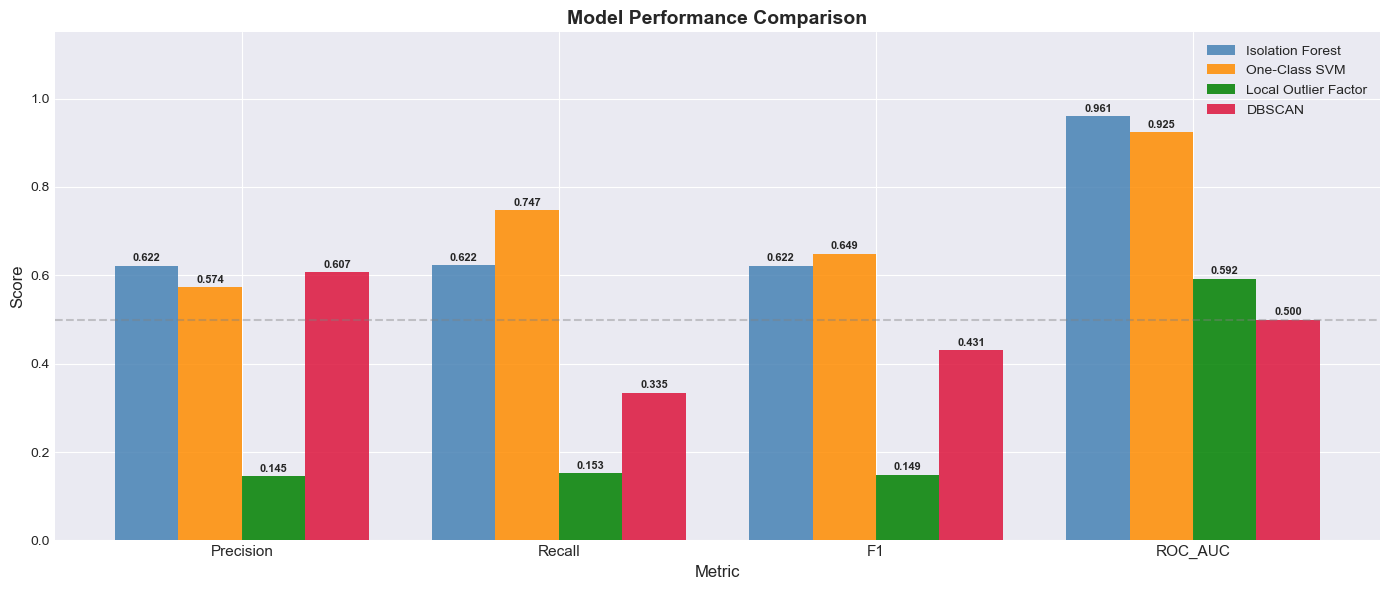

 Plot saved!


In [11]:
metrics = ['Precision', 'Recall', 'F1', 'ROC_AUC']
models  = results_df['Model'].tolist()
x       = np.arange(len(metrics))
width   = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['steelblue', 'darkorange', 'green', 'crimson']

for i, (model, color) in enumerate(zip(models, colors)):
    vals = results_df[results_df['Model'] == model][metrics].values[0]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    
    # Add value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Baseline')

plt.tight_layout()
plt.savefig("results/plots/model_comparison_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved!")

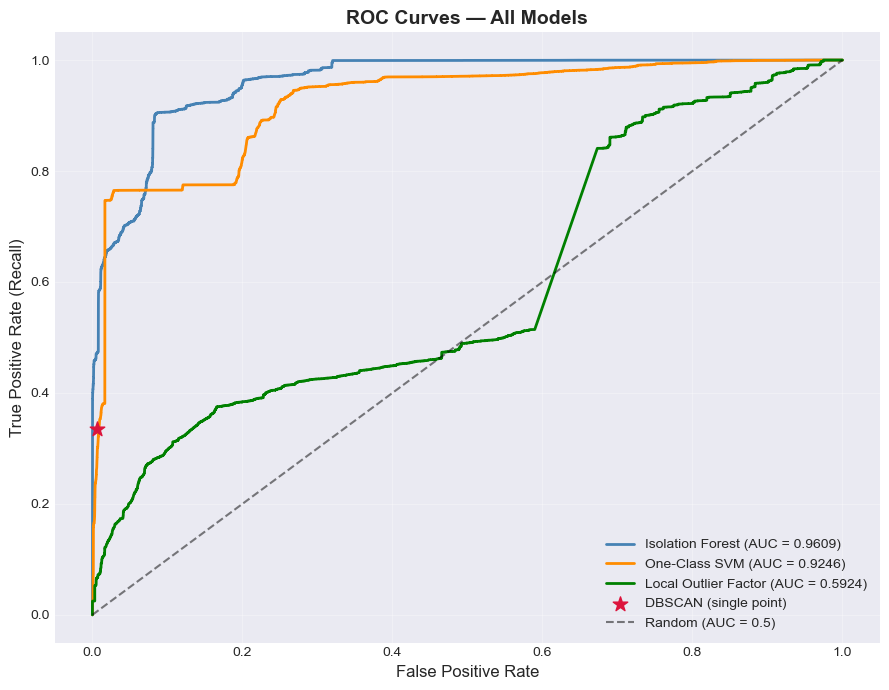

 ROC curve saved!


In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

# Plot ROC curve for models that have continuous scores
score_map = {
    'Isolation Forest'    : iso_scores_neg,
    'One-Class SVM'       : ocsvm_scores,
    'Local Outlier Factor': lof_scores,
}

colors = ['steelblue', 'darkorange', 'green']

for (model_name, scores), color in zip(score_map.items(), colors):
    fpr_arr, tpr_arr, _ = roc_curve(y, scores)
    auc_val = roc_auc_score(y, scores)
    ax.plot(fpr_arr, tpr_arr, color=color, lw=2,
            label=f'{model_name} (AUC = {auc_val:.4f})')

# DBSCAN — binary only, plot as single point
dbscan_binary = np.where(dbscan_preds == -1, 1, 0)
db_fpr = results_df[results_df['Model']=='DBSCAN']['FPR'].values[0]
db_tpr = results_df[results_df['Model']=='DBSCAN']['Recall'].values[0]
ax.scatter([db_fpr], [db_tpr], color='crimson', s=120, zorder=5,
           label=f'DBSCAN (single point)', marker='*')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/plots/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(" ROC curve saved!")

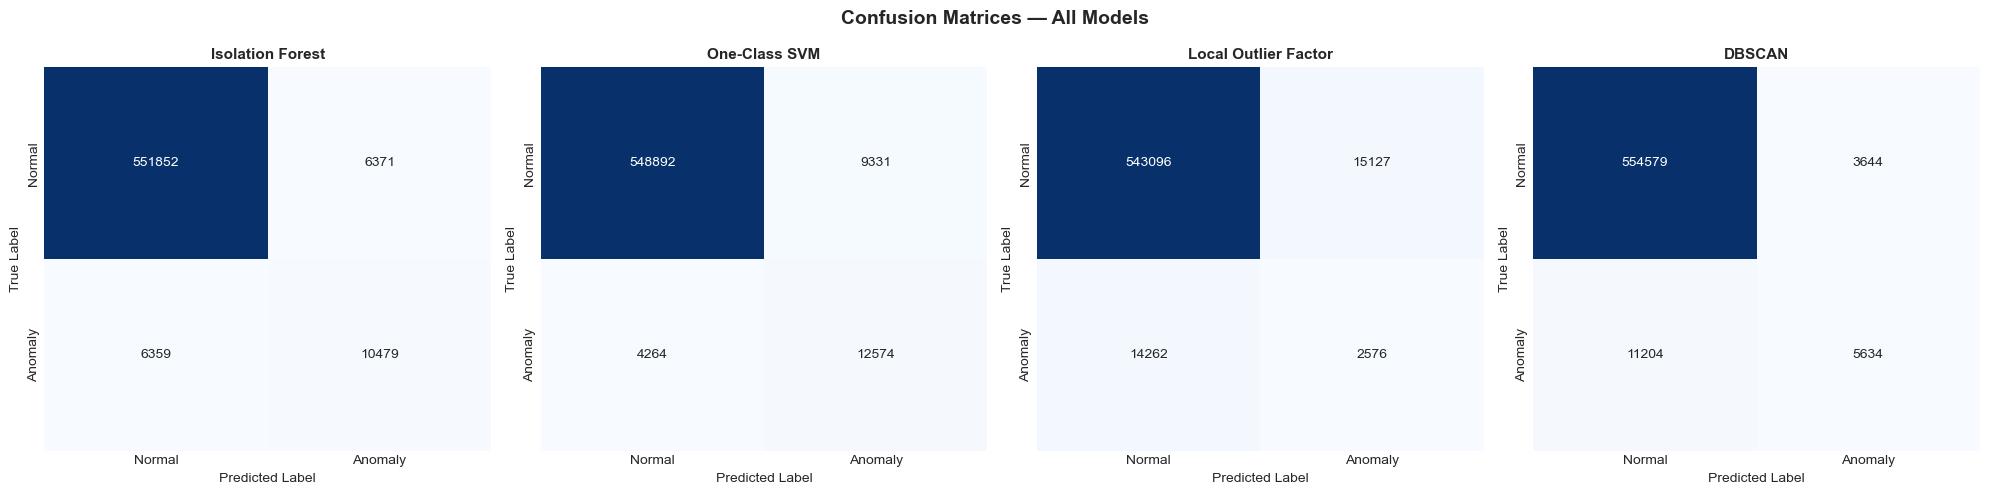

 Confusion matrices saved!


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_preds = {
    'Isolation Forest'    : iso_preds,
    'One-Class SVM'       : ocsvm_preds,
    'Local Outlier Factor': lof_preds,
    'DBSCAN'              : dbscan_preds
}

for ax, (model_name, preds) in zip(axes, model_preds.items()):
    y_pred_bin = np.where(preds == -1, 1, 0)
    cm = confusion_matrix(y, y_pred_bin)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'],
                cbar=False)
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("results/plots/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrices saved!")

In [15]:
print("=" * 60)
print("        PHASE 4 COMPLETE — FINAL SUMMARY")
print("=" * 60)
print()
print(results_display[['Precision','Recall','F1','ROC_AUC','FPR']])
print()

# Identify best model per metric
print(" Best model per metric:")
for metric in ['Precision', 'Recall', 'F1', 'ROC_AUC']:
    best_idx   = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_val   = results_df.loc[best_idx, metric]
    print(f"   {metric:<12}: {best_model} ({best_val:.4f})")

print()
print(" All models trained, evaluated, and saved!")
print(" Results saved to results/metrics/model_comparison.csv")
print(" Plots saved to results/plots/")
print()
print(" Ready for Phase 5: Visualization & Deep Analysis!")

        PHASE 4 COMPLETE — FINAL SUMMARY

                      Precision  Recall      F1  ROC_AUC     FPR
Model                                                           
Isolation Forest         0.6219  0.6223  0.6221   0.9609  0.0114
One-Class SVM            0.5740  0.7468  0.6491   0.9246  0.0167
Local Outlier Factor     0.1455  0.1530  0.1492   0.5924  0.0271
DBSCAN                   0.6072  0.3346  0.4315   0.5000  0.0065

 Best model per metric:
   Precision   : Isolation Forest (0.6219)
   Recall      : One-Class SVM (0.7468)
   F1          : One-Class SVM (0.6491)
   ROC_AUC     : Isolation Forest (0.9609)

 All models trained, evaluated, and saved!
 Results saved to results/metrics/model_comparison.csv
 Plots saved to results/plots/

 Ready for Phase 5: Visualization & Deep Analysis!
